# 도심 침수 예측 — GNN 모델 비교 실험

서울시 하수관로·도로노면 수위 센서 데이터를 이종 그래프로 구성하고,
시공간 GNN 5개 모델을 동일한 조건 하에 학습·평가한다.

| # | 모델 | 공간 연산 | 시간 연산 | 특징 |
|---|------|----------|----------|------|
| 1 | **Baseline-LSTM** | 없음 | LSTM | 공간 정보 미사용, 기준선 |
| 2 | **GC-GRU** | GCNConv | GRU | 단순 그래프 컨볼루션 + 순환 |
| 3 | **Hetero-GAT-GRU** | GATConv (이종) | GRU | 엣지 어텐션, 이종 타입 처리 |
| 4 | **STGCN** | ChebConv | Conv1d | 순환 없음, 빠른 학습 |
| 5 | **DCRNN** | 확산 컨볼루션 | GRU | 교통 예측 SOTA 아키텍처 |

**예측 태스크**
- 회귀: `level_norm` (도로 수위, 60분 입력 → 30분 예측)
- 이진 분류: `flood_flag` (침수 여부)

**평가 지표**: MAE, RMSE (회귀) / F1, AUROC (이진 분류)

## 1. Imports 및 공통 설정

In [1]:
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.nn import GCNConv, GATConv, ChebConv
from torch_geometric.utils import add_self_loops
from torch_scatter import scatter_add

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    f1_score, roc_auc_score,
    average_precision_score,    # AUPRC — 불균형 데이터 핵심 지표
    precision_recall_curve,     # 최적 임계값 탐색
    precision_score, recall_score,
    r2_score,                   # R²
)
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 (NanumGothic) ─────────────────
fm._load_fontmanager(try_read_cache=False)
plt.rcParams.update({
    'font.family'        : 'NanumGothic',
    'axes.unicode_minus' : False,
})
print('한글 폰트:', plt.rcParams['font.family'])

# ── 디바이스 ─────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── 무손실 가속: TF32 matmul (Ampere+) — FP32 대비 정확도 영향 거의 없음 ──
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    print('TF32 활성화:', torch.cuda.get_device_name(0))

/home/namjun/city_flood/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


한글 폰트: ['NanumGothic']
Device: cuda


In [2]:
# ── 경로 ─────────────────────────────────────────
BASE     = Path('./dataset/features')
OVERLAP  = BASE / 'overlap'

# ── 하이퍼파라미터 ───────────────────────────────
CFG = {
    # 실험 규모
    # 'QUICK_RUN'  : True,   # [장마철 2개월 빠른 테스트] 공간 이득 미확인됨 → 전체 기간으로 전환
    'QUICK_RUN'  : False,  # 전체 기간 학습 — 공간 이득 재확인용
    'RESAMPLE'   : '10min',

    # 시계열
    'T_IN'       : 6,      # 입력 스텝 (60분)
    'T_OUT'      : 18,     # 예측 스텝 (180분)

    # 모델
    'HIDDEN'     : 64,
    'CHEB_K'     : 3,      # ChebConv 다항식 차수
    'DIFF_K'     : 2,      # DCRNN 확산 스텝
    'GAT_HEADS'  : 4,
    'DROPOUT'    : 0.1,

    # 학습
    'EPOCHS'     : 30,
    'BATCH'      : 128,
    'LR'         : 1e-3,
    'WEIGHT_DEC' : 1e-4,

    # 클래스 가중치 (gnn_config.json 기준)
    'POS_WEIGHT'  : 19.75,

    # 재현성
    'SEED'       : 42,
}

# gnn_config.json 읽기
with open(BASE / 'gnn_config.json', encoding='utf-8') as f:
    GNN_CFG = json.load(f)

N_SEWER = GNN_CFG['graph']['sewer_nodes']
N_ROAD  = GNN_CFG['graph']['road_nodes']
F_SEWER = len(GNN_CFG['node_features']['sewer'])
F_ROAD  = len(GNN_CFG['node_features']['road'])

print(f'하수 노드: {N_SEWER}, 도로 노드: {N_ROAD}')
print(f'하수 피처: {F_SEWER}dim, 도로 피처: {F_ROAD}dim')
print(f'T_in={CFG["T_IN"]}스텝 ({CFG["T_IN"]*10}분) → T_out={CFG["T_OUT"]}스텝 ({CFG["T_OUT"]*10}분)')
print(f'QUICK_RUN={CFG["QUICK_RUN"]} → {"장마철 2개월" if CFG["QUICK_RUN"] else "전체 기간 (공간 이득 재확인)"}')

# 시드 고정
torch.manual_seed(CFG['SEED'])
np.random.seed(CFG['SEED'])


하수 노드: 404, 도로 노드: 90
하수 피처: 10dim, 도로 피처: 10dim
T_in=6스텝 (60분) → T_out=18스텝 (180분)
QUICK_RUN=False → 전체 기간 (공간 이득 재확인)


## 2. 그래프 구조 로드

노드 인덱스와 엣지 (sewer→road, sewer→sewer)를 PyTorch 텐서로 변환한다.

In [3]:
# 노드 인덱스
sewer_idx = pd.read_parquet(BASE / 'sewer_node_index.parquet')
road_idx  = pd.read_parquet(BASE / 'road_node_index.parquet')

sewer_id2idx = sewer_idx.set_index('sensor_id')['node_idx'].to_dict()
road_id2idx  = road_idx.set_index('sensor_id')['node_idx'].to_dict()

# sewer → road 엣지
adj = pd.read_parquet(BASE / 'adjacency_expanded.parquet')
adj = adj[adj['sewer_id'].isin(sewer_id2idx) & adj['road_id'].isin(road_id2idx)]

sr_src = torch.tensor([sewer_id2idx[s] for s in adj['sewer_id']], dtype=torch.long)
sr_dst = torch.tensor([road_id2idx[r]  for r in adj['road_id']],  dtype=torch.long)
sr_ei  = torch.stack([sr_src, sr_dst], dim=0)           # (2, E_sr)
sr_ew  = torch.tensor(adj['gauss_weight'].values, dtype=torch.float32)

# sewer → sewer 엣지
ss = pd.read_parquet(BASE / 'sewer_sewer_edges.parquet')
ss = ss[ss['src_sewer_id'].isin(sewer_id2idx) & ss['dst_sewer_id'].isin(sewer_id2idx)]

ss_src = torch.tensor([sewer_id2idx[s] for s in ss['src_sewer_id']], dtype=torch.long)
ss_dst = torch.tensor([sewer_id2idx[d] for d in ss['dst_sewer_id']], dtype=torch.long)
# 양방향 대칭으로 구성 (undirected)
ss_ei  = torch.stack([torch.cat([ss_src, ss_dst]),
                       torch.cat([ss_dst, ss_src])], dim=0)   # (2, 2*E_ss)
ss_ew  = torch.cat([torch.tensor(ss['gauss_weight'].values, dtype=torch.float32)] * 2)

print(f'sewer→road 엣지: {sr_ei.shape[1]}개')
print(f'sewer→sewer 엣지 (양방향): {ss_ei.shape[1]}개')

# GPU 이동 (모델 안에서 사용)
SR_EI = sr_ei.to(DEVICE)
SR_EW = sr_ew.to(DEVICE)
SS_EI = ss_ei.to(DEVICE)
SS_EW = ss_ew.to(DEVICE)

sewer→road 엣지: 383개
sewer→sewer 엣지 (양방향): 2180개


## 3. 시계열 데이터 로드 및 텐서 변환

parquet → 10분 리샘플 → (T, N, F) 3D 텐서

In [20]:
import hashlib

SEWER_FEATS = GNN_CFG['node_features']['sewer']
ROAD_FEATS  = GNN_CFG['node_features']['road']

# 텐서 캐시 디렉터리 — 커널 재시작 시 재로드 불필요
TENSOR_CACHE = Path('./dataset/processed/tensor_cache')
TENSOR_CACHE.mkdir(exist_ok=True)


def _cache_path(path: Path, feat_cols: list, resample: str,
                agg: str, date_range) -> Path:
    """파일 크기 + 설정 해시 기반 캐시 경로 (parquet 변경 시 자동 무효화)"""
    st_size = path.stat().st_size if path.exists() else 0
    key = f"{path}|{st_size}|{sorted(feat_cols)}|{resample}|{agg}|{date_range}"
    h = hashlib.md5(key.encode()).hexdigest()[:10]
    return TENSOR_CACHE / f"{path.stem}_{h}.pt"


def load_tensor(path: Path, id2idx: dict, feat_cols: list,
                resample: str = '10min',
                agg: str = 'mean',
                date_range=None) -> tuple:
    """
    parquet → (T, N, F) float32 텐서

    개선 (vs 구버전):
      1. resample() → dt.floor() + groupby  (pandas resample 오버헤드 제거)
      2. iterrows() → 벡터화 numpy 인덱싱  (수백만 행도 즉시 처리)
      3. 디스크 캐시: 동일 설정 재실행 시 수초 내 로드
    """
    # ── 캐시 확인 ────────────────────────────────────────────
    cache = _cache_path(path, feat_cols, resample, agg, date_range)
    if cache.exists():
        data = torch.load(cache, weights_only=False)
        print(f'  [캐시 HIT] {cache.name}')
        return data['tensor'], data['times']

    # ── parquet 로드 ─────────────────────────────────────────
    df = pd.read_parquet(path, engine='pyarrow',
                         columns=['sensor_id', 'timestamp'] + feat_cols)
    df = df[df['sensor_id'].isin(id2idx)]
    if date_range:
        df = df[(df['timestamp'] >= date_range[0]) & (df['timestamp'] < date_range[1])]
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # ── 리샘플: resample() 대신 floor + groupby (2~5x 빠름) ──
    agg_fn = 'mean' if agg == 'mean' else 'max'
    df['_ts'] = df['timestamp'].dt.floor(resample)
    df = (df.groupby(['sensor_id', '_ts'])[feat_cols]
            .agg(agg_fn)
            .reset_index()
            .rename(columns={'_ts': 'timestamp'}))

    # ── 타임스텝 그리드 ──────────────────────────────────────
    times = sorted(df['timestamp'].unique())
    n_t   = len(times)
    n_n   = len(id2idx)
    n_f   = len(feat_cols)
    t_map = {t: i for i, t in enumerate(times)}

    # ── 벡터화 인덱싱 (iterrows 완전 대체) ─────────────────────
    # 구버전: for _, row in df.iterrows(): tensor[ti,ni,:] = ...  ← 40~50분
    t_idx = df['timestamp'].map(t_map).values.astype(np.int32)
    n_idx = df['sensor_id'].map(id2idx).values.astype(np.int32)
    vals  = df[feat_cols].values.astype(np.float32)

    tensor = np.zeros((n_t, n_n, n_f), dtype=np.float32)  # 결측 = 0 (Step03에서 처리됨)
    tensor[t_idx, n_idx, :] = vals  # 단일 numpy 인덱싱

    result = torch.from_numpy(tensor)
    torch.save({'tensor': result, 'times': times}, cache)
    print(f'  [캐시 저장] {cache.name}')
    return result, times


# ── 날짜 범위 설정 ────────────────────────────────────────────
if CFG['QUICK_RUN']:
    # 장마철 2개월 빠른 테스트용 — 공간 이득 미확인됨 → 전체 기간으로 전환
    RANGES = {
        'train': ('2024-06-01', '2024-08-31'),
        'val'  : ('2024-09-01', '2024-10-31'),
        'test' : ('2025-06-01', '2025-08-31'),
    }
    print('QUICK_RUN=True: 여름(장마) 기간만 로드')
else:
    # 전체 기간 — 공간 이득 재확인용
    RANGES = {
        'train': ('2024-01-01', '2024-12-31'),
        'val'  : ('2025-01-01', '2025-05-31'),
        'test' : ('2025-06-01', '2025-08-31'),
    }
    print('QUICK_RUN=False: 전체 기간 로드')

# ── 데이터 로드 루프 ──────────────────────────────────────────
TENSORS = {}
for split in ('train', 'val', 'test'):
    dr        = RANGES[split]
    src_split = 'train' if CFG['QUICK_RUN'] and split != 'test' else split

    t0 = time.time()
    print(f'\n[{split}] sewer 로드 중...')
    s_tensor, s_times = load_tensor(
        OVERLAP / src_split / f'sewer_{src_split}.parquet',
        sewer_id2idx, SEWER_FEATS, date_range=dr)

    print(f'[{split}] road 로드 중...')
    r_tensor, r_times = load_tensor(
        OVERLAP / src_split / f'road_{src_split}.parquet',
        road_id2idx, ROAD_FEATS, date_range=dr, agg='max')

    # 타임스텝 교집합 정렬
    common  = sorted(set(s_times) & set(r_times))
    s_tmap  = {t: i for i, t in enumerate(s_times)}
    r_tmap  = {t: i for i, t in enumerate(r_times)}
    s_idx_  = [s_tmap[t] for t in common]
    r_idx_  = [r_tmap[t] for t in common]

    TENSORS[split] = {
        'sewer' : s_tensor[s_idx_],   # (T, N_s, F_s)
        'road'  : r_tensor[r_idx_],   # (T, N_r, F_r)
        'times' : common,
    }
    T = len(common)
    print(f'  → {T:,} 타임스텝  sewer {tuple(s_tensor[s_idx_].shape)}'
          f'  road {tuple(r_tensor[r_idx_].shape)}  ({time.time()-t0:.1f}s)')

print('\n데이터 로드 완료')

QUICK_RUN=False: 전체 기간 로드

[train] sewer 로드 중...
  [캐시 HIT] sewer_train_ed4b999821.pt
[train] road 로드 중...
  [캐시 HIT] road_train_82bd08cfb0.pt
  → 52,560 타임스텝  sewer (52560, 404, 10)  road (52560, 90, 10)  (0.7s)

[val] sewer 로드 중...
  [캐시 HIT] sewer_val_80109bfaf7.pt
[val] road 로드 중...
  [캐시 HIT] road_val_55037afecc.pt
  → 21,600 타임스텝  sewer (21600, 404, 10)  road (21600, 90, 10)  (0.3s)

[test] sewer 로드 중...
  [캐시 HIT] sewer_test_ae87494a7d.pt
[test] road 로드 중...
  [캐시 HIT] road_test_c60b860a02.pt
  → 13,104 타임스텝  sewer (13104, 404, 10)  road (13104, 90, 10)  (0.2s)

데이터 로드 완료


## 4. 슬라이딩 윈도우 데이터셋

In [21]:
class FloodDataset(Dataset):
    """
    (T, N, F) 텐서에서 슬라이딩 윈도우로 샘플 생성

    반환:
      x_sewer : (N_s, T_in, F_s)
      x_road  : (N_r, T_in, F_r)
      y_reg   : (N_r, T_out)  — level_norm 타겟
      y_cls   : (N_r, T_out)  — flood_flag 타겟
    """
    LEVEL_NORM_IDX = 0  # ROAD_FEATS에서 level_norm 위치
    FLOOD_FLAG_IDX = 2  # ROAD_FEATS에서 flood_flag 위치

    def __init__(self, tensors: dict, t_in: int, t_out: int):
        self.s = tensors['sewer']   # (T, N_s, F_s)
        self.r = tensors['road']    # (T, N_r, F_r)
        self.t_in  = t_in
        self.t_out = t_out
        self.length = len(self.s) - t_in - t_out + 1

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        s_in = self.s[idx : idx + self.t_in]          # (T_in, N_s, F_s)
        r_in = self.r[idx : idx + self.t_in]          # (T_in, N_r, F_r)
        r_out = self.r[idx + self.t_in : idx + self.t_in + self.t_out]  # (T_out, N_r, F_r)

        x_sewer = s_in.permute(1, 0, 2)               # (N_s, T_in, F_s)
        x_road  = r_in.permute(1, 0, 2)               # (N_r, T_in, F_r)
        y_reg   = r_out[:, :, self.LEVEL_NORM_IDX].T  # (N_r, T_out)
        y_cls   = r_out[:, :, self.FLOOD_FLAG_IDX].T  # (N_r, T_out)

        return x_sewer, x_road, y_reg, y_cls


t_in, t_out = CFG['T_IN'], CFG['T_OUT']

# ── 무손실 가속: 텐서 GPU 상주 → 배치마다 H2D 전송·.float() 변환 제거 ──
if torch.cuda.is_available():
    for _split in TENSORS:
        for _key in ('sewer', 'road'):
            TENSORS[_split][_key] = TENSORS[_split][_key].to(DEVICE).float()

datasets = {k: FloodDataset(TENSORS[k], t_in, t_out) for k in ('train', 'val', 'test')}
loaders = {
    k: DataLoader(ds, batch_size=CFG['BATCH'],
                  shuffle=(k == 'train'), drop_last=False,
                  num_workers=0,            # GPU 상주 텐서 → 멀티워커 불가(필요도 없음)
                  pin_memory=False)         # 이미 GPU 상주 → pin 불필요
    for k, ds in datasets.items()
}

for k, ds in datasets.items():
    print(f'{k:5s}: {len(ds):,} 샘플 / {len(loaders[k])} 배치')

train: 52,537 샘플 / 411 배치
val  : 21,577 샘플 / 169 배치
test : 13,081 샘플 / 103 배치


## 5. 모델 정의

### 공통 인터페이스
```python
forward(x_sewer, x_road) → (pred_reg, pred_cls)
  x_sewer : (B, N_s, T_in, F_s)
  x_road  : (B, N_r, T_in, F_r)
  pred_reg: (B, N_r, T_out)  # level_norm
  pred_cls: (B, N_r, T_out)  # flood_flag logits
```

엣지 정보(`SR_EI`, `SR_EW`, `SS_EI`, `SS_EW`)는 전역 상수로 모델 내부에서 참조.

### 5.1 Baseline-LSTM (공간 정보 없음)

In [22]:
class BaselineLSTM(nn.Module):
    """하수관로 무시, 도로 노드 독립 LSTM — 공간 정보 미사용 기준선"""

    def __init__(self, f_road, hidden, t_out, n_road, dropout=0.1):
        super().__init__()
        self.n_road = n_road
        self.t_out  = t_out
        self.lstm   = nn.LSTM(f_road, hidden, num_layers=2,
                               batch_first=True, dropout=dropout)
        self.fc_reg = nn.Linear(hidden, t_out)
        self.fc_cls = nn.Linear(hidden, t_out)

    def forward(self, x_sewer, x_road):
        # x_road: (B, N_r, T_in, F_r)
        B, N, T, F = x_road.shape
        x = x_road.reshape(B * N, T, F)       # (B*N, T, F)
        _, (h, _) = self.lstm(x)              # h: (2, B*N, hidden)
        h = h[-1]                             # (B*N, hidden)
        reg = self.fc_reg(h).view(B, N, -1)   # (B, N_r, T_out)
        cls = self.fc_cls(h).view(B, N, -1)
        return reg, cls

### 5.2 GC-GRU (GCN + GRU)

각 타임스텝에서 GCNConv으로 sewer→road 메시지를 수집한 뒤 GRU로 시간 모델링.  
동종 그래프 근사: sewer(0..N_s-1) + road(N_s..N_s+N_r-1) 노드를 하나의 그래프로 처리.

In [23]:
class GCGRUCell(nn.Module):
    """GCN-GRU 셀: 공간 그래프 컨볼루션을 GRU 게이트에 적용"""

    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        # reset gate, update gate, candidate (각각 GCN)
        self.gcn_r = GCNConv(input_dim + hidden_dim, hidden_dim, add_self_loops=False)
        self.gcn_u = GCNConv(input_dim + hidden_dim, hidden_dim, add_self_loops=False)
        self.gcn_c = GCNConv(input_dim + hidden_dim, hidden_dim, add_self_loops=False)

    def forward(self, x, h, edge_index, edge_weight):
        # x, h: (total_nodes, dim)
        xh  = torch.cat([x, h], dim=-1)
        r   = torch.sigmoid(self.gcn_r(xh, edge_index, edge_weight))
        u   = torch.sigmoid(self.gcn_u(xh, edge_index, edge_weight))
        xrh = torch.cat([x, r * h], dim=-1)
        c   = torch.tanh(self.gcn_c(xrh, edge_index, edge_weight))
        return (1 - u) * h + u * c


class GCGRU(nn.Module):
    """GCN-GRU: 이종 그래프를 동종으로 근사하여 학습"""

    def __init__(self, f_sewer, f_road, hidden, t_out, n_sewer, n_road, dropout=0.1):
        super().__init__()
        self.n_s    = n_sewer
        self.n_r    = n_road
        self.hidden = hidden
        self.t_out  = t_out

        # 피처 차원 통일 (공통 hidden으로 투영)
        self.proj_s = nn.Linear(f_sewer, hidden)
        self.proj_r = nn.Linear(f_road,  hidden)

        self.cell   = GCGRUCell(hidden, hidden)
        self.drop   = nn.Dropout(dropout)
        self.fc_reg = nn.Linear(hidden, t_out)
        self.fc_cls = nn.Linear(hidden, t_out)

        # sewer+road 통합 엣지 (sewer offset=0, road offset=n_sewer)
        self._build_combined_edges()

    def _build_combined_edges(self):
        # sewer→road: dst에 n_sewer offset 추가
        sr_dst_shifted = SR_EI[1] + self.n_s
        sr_combined    = torch.stack([SR_EI[0], sr_dst_shifted])

        # sewer→sewer: 그대로
        ss_combined = SS_EI

        # 통합 + self-loop
        n_total     = self.n_s + self.n_r
        ei_combined = torch.cat([sr_combined, ss_combined], dim=1)
        ew_combined = torch.cat([SR_EW, SS_EW])
        ei_sl, ew_sl = add_self_loops(ei_combined, ew_combined,
                                       fill_value=1.0, num_nodes=n_total)
        self.register_buffer('ei', ei_sl)
        self.register_buffer('ew', ew_sl)

    def forward(self, x_sewer, x_road):
        # x_sewer: (B, N_s, T, F_s),  x_road: (B, N_r, T, F_r)
        B, N_s, T, _ = x_sewer.shape
        N_r = x_road.shape[1]
        N   = N_s + N_r

        # 피처 투영
        xs = self.proj_s(x_sewer)   # (B, N_s, T, H)
        xr = self.proj_r(x_road)    # (B, N_r, T, H)

        # 초기 은닉 상태
        h = torch.zeros(B, N, self.hidden, device=x_sewer.device)

        for t in range(T):
            # (B, N, H) → (B*N, H)로 reshape하여 GCN 적용
            x_t = torch.cat([xs[:, :, t, :], xr[:, :, t, :]], dim=1)  # (B, N, H)
            x_t_flat = x_t.reshape(B * N, self.hidden)
            h_flat   = h.reshape(B * N, self.hidden)

            # 배치 처리: 엣지 인덱스를 배치별로 오프셋
            ei_batch = self.ei.repeat(1, B) + \
                       (torch.arange(B, device=x_sewer.device).repeat_interleave(
                           self.ei.shape[1]) * N).unsqueeze(0).repeat(2, 1)
            ew_batch = self.ew.repeat(B)

            h_flat = self.cell(x_t_flat, h_flat, ei_batch, ew_batch)
            h = h_flat.reshape(B, N, self.hidden)

        # 도로 노드만 예측
        h_road = self.drop(h[:, N_s:, :])   # (B, N_r, H)
        return self.fc_reg(h_road), self.fc_cls(h_road)

### 5.3 Hetero-GAT-GRU (이종 그래프 어텐션 + GRU)

sewer→road 메시지에 멀티헤드 어텐션을 적용하여 이웃 하수관의 중요도를 동적으로 학습.

In [24]:
class HeteroGATGRU(nn.Module):
    """이종 그래프 어텐션으로 sewer→road 집계 후 GRU 시간 모델링"""

    def __init__(self, f_sewer, f_road, hidden, t_out, n_road, heads=4, dropout=0.1):
        super().__init__()
        self.n_r    = n_road
        self.hidden = hidden
        self.t_out  = t_out

        # sewer→sewer GCN (하수관로 내부 공간 컨텍스트)
        self.gcn_ss = GCNConv(f_sewer, hidden, add_self_loops=True)

        # sewer→road GAT (이종 메시지 패싱)
        # src=sewer(hidden), dst=road(f_road) → concat → hidden
        self.gat_sr = GATConv(
            in_channels=(hidden, f_road),   # (src_dim, dst_dim)
            out_channels=hidden // heads,
            heads=heads,
            dropout=dropout,
            add_self_loops=False,
        )
        # GAT 출력: (N_r, hidden//heads * heads) = (N_r, hidden)

        # 도로 노드: aggregated + raw road feature → GRU
        self.proj_r = nn.Linear(f_road, hidden)
        self.gru    = nn.GRU(hidden * 2, hidden, num_layers=2,
                              batch_first=True, dropout=dropout)
        self.drop   = nn.Dropout(dropout)
        self.fc_reg = nn.Linear(hidden, t_out)
        self.fc_cls = nn.Linear(hidden, t_out)

    def forward(self, x_sewer, x_road):
        # x_sewer: (B, N_s, T, F_s),  x_road: (B, N_r, T, F_r)
        B, N_s, T, F_s = x_sewer.shape
        N_r = x_road.shape[1]

        road_seq = []
        for t in range(T):
            xs_t = x_sewer[:, :, t, :].reshape(B * N_s, F_s)   # (B*N_s, F_s)
            xr_t = x_road[:, :, t, :].reshape(B * N_r, -1)     # (B*N_r, F_r)

            # --- sewer 내부 GCN ---
            ei_ss_b = SS_EI.repeat(1, B) + \
                      (torch.arange(B, device=x_sewer.device)
                       .repeat_interleave(SS_EI.shape[1]) * N_s).unsqueeze(0).repeat(2, 1)
            ew_ss_b = SS_EW.repeat(B)
            hs_t = F.relu(self.gcn_ss(xs_t, ei_ss_b, ew_ss_b))  # (B*N_s, hidden)

            # --- sewer→road GAT ---
            ei_sr_b_src = SR_EI[0].repeat(B) + \
                          torch.arange(B, device=x_sewer.device).repeat_interleave(
                              SR_EI.shape[1]) * N_s
            ei_sr_b_dst = SR_EI[1].repeat(B) + \
                          torch.arange(B, device=x_sewer.device).repeat_interleave(
                              SR_EI.shape[1]) * N_r
            ei_sr_b = torch.stack([ei_sr_b_src, ei_sr_b_dst])

            agg_t = self.gat_sr((hs_t, xr_t), ei_sr_b)  # (B*N_r, hidden)

            # road raw projection
            xr_proj = self.proj_r(xr_t)                 # (B*N_r, hidden)

            # 결합
            combined = torch.cat([agg_t, xr_proj], dim=-1)  # (B*N_r, 2*hidden)
            road_seq.append(combined.view(B, N_r, -1))       # (B, N_r, 2H)

        # road_seq: T × (B, N_r, 2H) → (B*N_r, T, 2H)
        seq = torch.stack(road_seq, dim=2)          # (B, N_r, T, 2H)
        seq = seq.reshape(B * N_r, T, -1)
        _, h = self.gru(seq)                        # h: (2, B*N_r, hidden)
        h    = self.drop(h[-1]).reshape(B, N_r, self.hidden)
        return self.fc_reg(h), self.fc_cls(h)

### 5.4 STGCN (Spatial-Temporal Graph Convolutional Network)

Yu et al. 2018 스타일: ChebConv 공간 블록 + Conv1d 시간 블록 교차 반복.  
GRU 없이 순수 컨볼루션만 사용 → 병렬화 용이, 빠른 학습.

In [25]:
class STBlock(nn.Module):
    """Spatial-Temporal 블록: ChebConv → GLU temporal Conv → BN"""

    def __init__(self, c_in, c_out, t_len, k_cheb=3, kt=3, dropout=0.1):
        super().__init__()
        self.spatial = ChebConv(c_in,    c_out, K=k_cheb, normalization='sym')
        # GLU: 출력 채널 2배 (절반은 게이팅)
        self.temporal = nn.Sequential(
            nn.Conv1d(c_out, c_out * 2, kernel_size=kt, padding=kt // 2),
            nn.GLU(dim=1),      # (B*N, c_out, T)
        )
        self.bn   = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.res  = nn.Linear(c_in, c_out) if c_in != c_out else nn.Identity()

    def forward(self, x, edge_index, edge_weight):
        # x: (B*N, T, C_in)
        BN, T, C = x.shape
        # Spatial: apply on each timestep
        x_s = x.reshape(BN, T, C)
        outs = []
        for t in range(T):
            outs.append(F.relu(self.spatial(x_s[:, t, :], edge_index, edge_weight)))
        x_s = torch.stack(outs, dim=1)               # (BN, T, C_out)

        # Temporal: Conv1d over time
        x_t = x_s.permute(0, 2, 1)                   # (BN, C_out, T)
        x_t = self.temporal(x_t)                     # (BN, C_out, T)
        x_t = x_t.permute(0, 2, 1)                   # (BN, T, C_out)

        # Residual + BN
        res = self.res(x)
        out = self.bn((x_t + res).reshape(BN * T, -1)).reshape(BN, T, -1)
        return self.drop(out)


class STGCN(nn.Module):
    """Spatial-Temporal GCN — 이종 그래프 동종 근사"""

    def __init__(self, f_sewer, f_road, hidden, t_in, t_out,
                 n_sewer, n_road, k_cheb=3, n_blocks=2, dropout=0.1):
        super().__init__()
        self.n_s    = n_sewer
        self.n_r    = n_road
        self.t_in   = t_in
        self.t_out  = t_out
        self.hidden = hidden

        self.proj_s = nn.Linear(f_sewer, hidden)
        self.proj_r = nn.Linear(f_road,  hidden)

        self.blocks = nn.ModuleList([
            STBlock(hidden if i > 0 else hidden, hidden, t_in, k_cheb=k_cheb)
            for i in range(n_blocks)
        ])

        self.fc_reg = nn.Linear(hidden * t_in, t_out)
        self.fc_cls = nn.Linear(hidden * t_in, t_out)

        self._build_combined_edges()

    def _build_combined_edges(self):
        sr_dst_shifted = SR_EI[1] + self.n_s
        ei = torch.cat([torch.stack([SR_EI[0], sr_dst_shifted]), SS_EI], dim=1)
        ew = torch.cat([SR_EW, SS_EW])
        n_total = self.n_s + self.n_r
        ei_sl, ew_sl = add_self_loops(ei, ew, fill_value=1.0, num_nodes=n_total)
        self.register_buffer('ei', ei_sl)
        self.register_buffer('ew', ew_sl)

    def forward(self, x_sewer, x_road):
        B, N_s, T, _ = x_sewer.shape
        N_r = x_road.shape[1]
        N   = N_s + N_r

        xs = self.proj_s(x_sewer)    # (B, N_s, T, H)
        xr = self.proj_r(x_road)     # (B, N_r, T, H)
        x  = torch.cat([xs, xr], dim=1)  # (B, N, T, H)
        x  = x.reshape(B * N, T, self.hidden)

        # 배치 엣지 확장
        ei_b = self.ei.repeat(1, B) + \
               (torch.arange(B, device=x.device)
                .repeat_interleave(self.ei.shape[1]) * N).unsqueeze(0).repeat(2, 1)
        ew_b = self.ew.repeat(B)

        for blk in self.blocks:
            x = blk(x, ei_b, ew_b)

        # 도로 노드 추출 후 예측
        x = x.reshape(B, N, T, self.hidden)
        h = x[:, N_s:, :, :].reshape(B, N_r, -1)  # (B, N_r, T*H)
        return self.fc_reg(h), self.fc_cls(h)

### 5.5 DCRNN (Diffusion Convolutional Recurrent Neural Network)

Li et al. 2018 — 교통 속도 예측 SOTA 아키텍처를 침수 예측에 적용.  
확산 컨볼루션 `Z = Σ_k θ_k (D⁻¹A)^k X` 을 GRU 게이트에 내장.

In [26]:
class DiffusionConv(nn.Module):
    """K단계 확산 컨볼루션 (단방향)"""

    def __init__(self, input_dim, output_dim, K=2):
        super().__init__()
        self.K   = K
        self.lin = nn.Linear((K + 1) * input_dim, output_dim)

    def forward(self, x, support):
        # x: (B*N, F),  support: sparse 또는 dense (N, N)
        xs = [x]
        x_k = x
        for _ in range(self.K):
            x_k = torch.sparse.mm(support, x_k) if support.is_sparse \
                  else support @ x_k
            xs.append(x_k)
        return self.lin(torch.cat(xs, dim=-1))


class DCRNNCell(nn.Module):
    """확산 컨볼루션이 내장된 GRU 셀"""

    def __init__(self, input_dim, hidden_dim, K=2):
        super().__init__()
        self.dc_r = DiffusionConv(input_dim + hidden_dim, hidden_dim, K)
        self.dc_u = DiffusionConv(input_dim + hidden_dim, hidden_dim, K)
        self.dc_c = DiffusionConv(input_dim + hidden_dim, hidden_dim, K)

    def forward(self, x, h, support):
        xh  = torch.cat([x, h], dim=-1)
        r   = torch.sigmoid(self.dc_r(xh, support))
        u   = torch.sigmoid(self.dc_u(xh, support))
        xrh = torch.cat([x, r * h], dim=-1)
        c   = torch.tanh(self.dc_c(xrh, support))
        return (1 - u) * h + u * c


class DCRNN(nn.Module):
    """Diffusion Convolutional RNN"""

    def __init__(self, f_sewer, f_road, hidden, t_out,
                 n_sewer, n_road, K=2, dropout=0.1):
        super().__init__()
        self.n_s    = n_sewer
        self.n_r    = n_road
        self.n_tot  = n_sewer + n_road
        self.hidden = hidden
        self.t_out  = t_out

        self.proj_s = nn.Linear(f_sewer, hidden)
        self.proj_r = nn.Linear(f_road,  hidden)

        self.cell   = DCRNNCell(hidden, hidden, K)
        self.drop   = nn.Dropout(dropout)
        self.fc_reg = nn.Linear(hidden, t_out)
        self.fc_cls = nn.Linear(hidden, t_out)

        self._build_support()

    def _build_support(self):
        """정규화 인접행렬 D^-1 A를 dense 텐서로 구성"""
        N = self.n_tot
        A = torch.zeros(N, N)

        # sewer→road
        for i in range(SR_EI.shape[1]):
            s, r = SR_EI[0, i].item(), SR_EI[1, i].item() + self.n_s
            A[s, r] = SR_EW[i].item()

        # sewer→sewer (양방향)
        for i in range(SS_EI.shape[1]):
            s, d = SS_EI[0, i].item(), SS_EI[1, i].item()
            A[s, d] = SS_EW[i].item()

        # D^-1 정규화
        deg = A.sum(dim=1, keepdim=True).clamp(min=1e-6)
        support = A / deg
        self.register_buffer('support', support)

    def forward(self, x_sewer, x_road):
        B, N_s, T, _ = x_sewer.shape
        N_r = x_road.shape[1]
        N   = N_s + N_r

        xs = self.proj_s(x_sewer)    # (B, N_s, T, H)
        xr = self.proj_r(x_road)     # (B, N_r, T, H)

        # 배치 확장: support를 block-diagonal로
        sup = self.support  # (N, N) — 배치 내 모든 샘플 공유

        h = torch.zeros(B, N, self.hidden, device=x_sewer.device)

        for t in range(T):
            x_t = torch.cat([xs[:, :, t, :], xr[:, :, t, :]], dim=1)  # (B, N, H)
            h_new = torch.zeros_like(h)
            for b in range(B):
                h_new[b] = self.cell(x_t[b], h[b], sup)  # (N, H)
            h = h_new

        h_road = self.drop(h[:, N_s:, :])   # (B, N_r, H)
        return self.fc_reg(h_road), self.fc_cls(h_road)

## 6. 학습 및 평가 프레임워크

In [ ]:
# ── 평가 지표: torchmetrics(GPU)로 분류 정렬 연산 가속 (sklearn CPU 병목 제거) ──
#   sklearn 대비 전 지표 1e-7 이내 일치 검증 완료 (무손실), 분류 정렬 ~20x 가속
from torchmetrics.functional.classification import (
    binary_average_precision, binary_auroc, binary_precision_recall_curve)


def compute_metrics(y_reg_true, y_reg_pred, y_cls_true, y_cls_logit,
                    threshold=None, t_out=None, res_min=10):
    """
    입력: numpy 또는 GPU 텐서 (samples, N_r, T_out)
    반환: (metrics_dict, best_threshold)

    필수 지표 (EVALUATION_FRAMEWORK.md §7)
      회귀  : MAE, RMSE, R² (전체) + MAE/RMSE @각 horizon
      분류  : AUPRC(주), AUROC(보조), F1, Recall, Precision, CSI
      공간  : NodeMAE 중앙값, P90

    구버전(sklearn/CPU) 대비:
      - 분류 3개(AUPRC·AUROC·PR커브)를 GPU 정렬로 → eval idle 제거
      - F1/Precision/Recall은 TP/FP/FN 직접 계산 (CPU sklearn 호출 제거)
      - 전 지표 sklearn과 1e-7 이내 일치 (무손실 검증 완료)
    """
    dev = DEVICE
    rt = torch.nan_to_num(torch.as_tensor(y_reg_true,  dtype=torch.float32, device=dev))
    rp = torch.nan_to_num(torch.as_tensor(y_reg_pred,  dtype=torch.float32, device=dev))
    ct = torch.nan_to_num(torch.as_tensor(y_cls_true,  dtype=torch.float32, device=dev))
    cl = torch.nan_to_num(torch.as_tensor(y_cls_logit, dtype=torch.float32, device=dev))
    if t_out is None:
        t_out = rt.shape[2]

    # ── 회귀 (GPU) ────────────────────────────────
    diff = (rt - rp).abs()
    mae  = diff.mean().item()
    rmse = ((rt - rp) ** 2).mean().sqrt().item()
    ss_res = ((rt - rp) ** 2).sum()
    ss_tot = ((rt - rt.mean()) ** 2).sum()
    r2 = (1 - ss_res / (ss_tot + 1e-12)).item()

    # Horizon별 / Node별
    step_mae  = diff.mean(dim=(0, 1))                       # (T_out,)
    step_rmse = ((rt - rp) ** 2).mean(dim=(0, 1)).sqrt()
    node_mae  = diff.mean(dim=(0, 2))                       # (N_r,)
    node_mae_median = node_mae.median().item()
    node_mae_p90    = torch.quantile(node_mae, 0.90).item()

    # ── 분류 (GPU) ────────────────────────────────
    prob = torch.sigmoid(cl).ravel()
    tcls = ct.ravel().long()
    try:    auprc = binary_average_precision(prob, tcls, thresholds=None).item()
    except: auprc = float('nan')
    try:    auroc = binary_auroc(prob, tcls, thresholds=None).item()
    except: auroc = float('nan')

    # 최적 임계값: PR 곡선 F1 최대화
    if threshold is None:
        P, R, TH = binary_precision_recall_curve(prob, tcls, thresholds=None)
        f1_c = 2 * P[:-1] * R[:-1] / (P[:-1] + R[:-1] + 1e-9)
        threshold = (float(TH[int(torch.argmax(torch.nan_to_num(f1_c)))])
                     if f1_c.numel() > 0 else 0.5)

    pred = (prob >= threshold)
    tb   = tcls.bool()
    tp = (pred & tb).sum().item()
    fp = (pred & ~tb).sum().item()
    fn = (~pred & tb).sum().item()
    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    csi       = tp / (tp + fp + fn + 1e-9)

    metrics = {
        # 회귀 전체
        'MAE'  : float(mae),
        'RMSE' : float(rmse),
        'R2'   : float(r2),
        # 분류
        'threshold' : float(threshold),
        'AUPRC'     : float(auprc),
        'AUROC'     : float(auroc),
        'F1'        : float(f1),
        'Precision' : float(precision),
        'Recall'    : float(recall),
        'CSI'       : float(csi),
        # Node-wise 공간 성능
        'NodeMAE_median' : float(node_mae_median),
        'NodeMAE_P90'    : float(node_mae_p90),
    }
    # Horizon별 (T_out 전체)
    for i in range(t_out):
        label = f'@{(i + 1) * res_min}min'
        metrics[f'MAE{label}']  = float(step_mae[i].item())
        metrics[f'RMSE{label}'] = float(step_rmse[i].item())

    return metrics, threshold


def train_epoch(model, loader, optimizer, pos_weight, device):
    model.train()
    total_loss = 0.0
    pw = torch.tensor([pos_weight], device=device)

    for x_s, x_r, y_reg, y_cls in loader:
        x_s   = x_s.to(device).float()
        x_r   = x_r.to(device).float()
        y_reg = y_reg.to(device).float()
        y_cls = y_cls.to(device).float()

        optimizer.zero_grad()
        pred_reg, pred_cls = model(x_s, x_r)

        loss_reg = F.mse_loss(pred_reg, y_reg)
        loss_cls = F.binary_cross_entropy_with_logits(
            pred_cls, y_cls, pos_weight=pw)
        loss = loss_reg + loss_cls

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def eval_epoch(model, loader, device, threshold=None, save_preds=False):
    model.eval()
    all_reg_true, all_reg_pred = [], []
    all_cls_true, all_cls_pred = [], []

    for x_s, x_r, y_reg, y_cls in loader:
        x_s = x_s.to(device).float()
        x_r = x_r.to(device).float()
        pred_reg, pred_cls = model(x_s, x_r)

        # GPU 텐서 유지 (CPU 전송·numpy 변환 제거) → compute_metrics가 GPU에서 처리
        all_reg_true.append(y_reg.to(device))
        all_reg_pred.append(pred_reg)
        all_cls_true.append(y_cls.to(device))
        all_cls_pred.append(pred_cls)

    y_rr = torch.cat(all_reg_true)   # (samples, N_r, T_out)
    y_rp = torch.cat(all_reg_pred)
    y_cr = torch.cat(all_cls_true)
    y_cp = torch.cat(all_cls_pred)

    metrics, threshold = compute_metrics(y_rr, y_rp, y_cr, y_cp, threshold=threshold)

    if save_preds:
        # 후처리(a033b 등)는 numpy 기대 → test 1회만 변환
        preds = {'reg_true': y_rr.cpu().numpy(), 'reg_pred': y_rp.cpu().numpy(),
                 'cls_true': y_cr.cpu().numpy(), 'cls_logit': y_cp.cpu().numpy()}
        return metrics, threshold, preds
    return metrics, threshold


In [28]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def run_experiment(name, model, cfg, loaders, device):
    """단일 모델 전체 학습 + 평가 실행"""
    model = model.to(device)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=cfg['LR'], weight_decay=cfg['WEIGHT_DEC'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg['EPOCHS'])

    n_params = count_params(model)
    print(f'\n{"="*60}')
    print(f'  {name}  ({n_params:,} 파라미터)')
    print(f'{"="*60}')

    history = {
        'train_loss': [], 'val_mae': [],
        'val_f1': [], 'val_auprc': [], 'val_csi': [],
    }
    best_val_auprc = -1.0
    best_state     = None
    best_threshold = 0.5
    epoch_times    = []

    for epoch in range(1, cfg['EPOCHS'] + 1):
        t0   = time.time()
        loss = train_epoch(model, loaders['train'], optimizer, cfg['POS_WEIGHT'], device)
        # val_m, val_thr = eval_epoch(model, loaders['val'], device)
        # 매 2에폭마다 평가 (홀수 에폭은 이전 결과 재사용)
        if epoch % 2 == 0 or epoch == 1 or epoch == cfg['EPOCHS']:
            val_m, val_thr = eval_epoch(model, loaders['val'], device)
        scheduler.step()
        elapsed = time.time() - t0
        epoch_times.append(elapsed)

        history['train_loss'].append(loss)
        history['val_mae'].append(val_m['MAE'])
        history['val_f1'].append(val_m['F1'])
        history['val_auprc'].append(val_m['AUPRC'])
        history['val_csi'].append(val_m['CSI'])

        # 최고 모델: AUPRC 기준 (불균형 데이터에서 AUROC보다 신뢰도 높음)
        if val_m['AUPRC'] > best_val_auprc:
            best_val_auprc = val_m['AUPRC']
            best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_threshold = val_thr

        if epoch % 5 == 0 or epoch == 1:
            print(f'  epoch {epoch:3d} | loss={loss:.4f} '
                  f'| val MAE={val_m["MAE"]:.4f} '
                  f'AUPRC={val_m["AUPRC"]:.4f} '
                  f'F1={val_m["F1"]:.4f} '
                  f'Recall={val_m["Recall"]:.4f} '
                  f'CSI={val_m["CSI"]:.4f} '
                  f'| {elapsed:.1f}s')

    # 최고 모델(val AUPRC 기준)로 테스트 평가 + 예측 배열 저장
    model.load_state_dict(best_state)
    model.to(device)
    test_m, test_thr, preds = eval_epoch(
        model, loaders['test'], device,
        threshold=best_threshold, save_preds=True)

    t_out = cfg['T_OUT']
    res   = 10  # 분 해상도
    # 보고 horizon: 10min, 30min, 60min, 마지막 step
    report_steps = sorted(set([1, 3, 6, t_out]) & set(range(1, t_out + 1)))

    print(f'\n  [TEST] '
          f'MAE={test_m["MAE"]:.4f}  RMSE={test_m["RMSE"]:.4f}  R²={test_m["R2"]:.4f}')
    print(f'         '
          f'AUPRC={test_m["AUPRC"]:.4f}  AUROC={test_m["AUROC"]:.4f}  '
          f'F1={test_m["F1"]:.4f}  Recall={test_m["Recall"]:.4f}  '
          f'Precision={test_m["Precision"]:.4f}  CSI={test_m["CSI"]:.4f}')
    step_str = '  '.join(
        f'MAE@{s*res}min={test_m[f"MAE@{s*res}min"]:.4f}' for s in report_steps
    )
    print(f'         {step_str}')
    print(f'         '
          f'NodeMAE(중앙값)={test_m["NodeMAE_median"]:.4f}  '
          f'NodeMAE(P90)={test_m["NodeMAE_P90"]:.4f}  '
          f'임계값={test_thr:.4f}')

    return {
        'name'       : name,
        'n_params'   : n_params,
        'test'       : test_m,
        'preds'      : preds,
        'threshold'  : test_thr,
        'history'    : history,
        'avg_epoch_s': float(np.mean(epoch_times)),
    }

## 7. 실험 실행

5개 모델을 순차 학습한다. GPU가 없으면 `QUICK_RUN=True` 상태로 실행을 권장한다.

In [29]:
# ── NaN 긴급 패치 ── 실험 실행 전 반드시 먼저 실행
import numpy as np

# 1) 텐서 내 NaN 제거
for split in TENSORS:
    for key in ('sewer', 'road'):
        t = TENSORS[split][key]
        nan_mask = t.isnan()
        if nan_mask.any():
            print(f'  [{split}][{key}] NaN {nan_mask.sum().item():,}개 → 0으로 치환')
            t[nan_mask] = 0.0

# 2) compute_metrics NaN 방어 패치
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
    average_precision_score, roc_auc_score, f1_score, precision_score,
    recall_score, precision_recall_curve)

def compute_metrics(y_reg_true, y_reg_pred, y_cls_true, y_cls_logit,
                    threshold=None, t_out=None, res_min=10):
    if t_out is None:
        t_out = y_reg_true.shape[2]
    y_reg_true  = np.nan_to_num(y_reg_true,  nan=0.0)
    y_reg_pred  = np.nan_to_num(y_reg_pred,  nan=0.0)
    y_cls_true  = np.nan_to_num(y_cls_true,  nan=0.0)
    y_cls_logit = np.nan_to_num(y_cls_logit, nan=0.0)

    flat_true = y_reg_true.ravel();  flat_pred = y_reg_pred.ravel()
    mae  = mean_absolute_error(flat_true, flat_pred)
    rmse = mean_squared_error(flat_true, flat_pred) ** 0.5
    r2   = r2_score(flat_true, flat_pred)
    diff = np.abs(y_reg_true - y_reg_pred)
    step_mae  = np.mean(diff, axis=(0,1));  step_rmse = np.sqrt(np.mean((y_reg_true-y_reg_pred)**2, axis=(0,1)))
    node_mae  = np.mean(diff, axis=(0,2))
    prob     = 1.0 / (1.0 + np.exp(-y_cls_logit.ravel()))
    true_cls = y_cls_true.ravel().astype(int)
    try:    auprc = float(average_precision_score(true_cls, prob))
    except: auprc = float('nan')
    try:    auroc = float(roc_auc_score(true_cls, prob))
    except: auroc = float('nan')
    if threshold is None:
        prec_c, rec_c, thr_c = precision_recall_curve(true_cls, prob)
        f1_c = 2*prec_c[:-1]*rec_c[:-1]/(prec_c[:-1]+rec_c[:-1]+1e-9)
        threshold = float(thr_c[int(np.nanargmax(f1_c))]) if len(f1_c)>0 else 0.5
    pred = (prob >= threshold).astype(int)
    f1 = float(f1_score(true_cls, pred, zero_division=0))
    precision = float(precision_score(true_cls, pred, zero_division=0))
    recall    = float(recall_score(true_cls, pred, zero_division=0))
    tp = int(np.sum((pred==1)&(true_cls==1)));  fp = int(np.sum((pred==1)&(true_cls==0)));  fn = int(np.sum((pred==0)&(true_cls==1)))
    csi = tp/(tp+fp+fn+1e-9)
    metrics = {'MAE':float(mae),'RMSE':float(rmse),'R2':float(r2),
               'threshold':float(threshold),'AUPRC':float(auprc),'AUROC':float(auroc),
               'F1':float(f1),'Precision':float(precision),'Recall':float(recall),'CSI':float(csi),
               'NodeMAE_median':float(np.median(node_mae)),'NodeMAE_P90':float(np.percentile(node_mae,90))}
    for i in range(t_out):
        metrics[f'MAE@{(i+1)*res_min}min']=float(step_mae[i]);  metrics[f'RMSE@{(i+1)*res_min}min']=float(step_rmse[i])
    return metrics, threshold

print('패치 완료 — 이제 실험 셀 실행')

  [train][sewer] NaN 4,417,248개 → 0으로 치환
  [train][road] NaN 675,457개 → 0으로 치환
  [val][sewer] NaN 2,076,735개 → 0으로 치환
  [val][road] NaN 315,150개 → 0으로 치환
  [test][sewer] NaN 1,783,249개 → 0으로 치환
  [test][road] NaN 270,730개 → 0으로 치환
패치 완료 — 이제 실험 셀 실행


In [30]:
# 모델 팩토리
def make_models(cfg, n_s, n_r, f_s, f_r, t_in, t_out):
    H = cfg['HIDDEN']
    return {
        'Baseline-LSTM' : BaselineLSTM(
            f_road=f_r, hidden=H, t_out=t_out, n_road=n_r,
            dropout=cfg['DROPOUT']),

        'GC-GRU' : GCGRU(
            f_sewer=f_s, f_road=f_r, hidden=H, t_out=t_out,
            n_sewer=n_s, n_road=n_r, dropout=cfg['DROPOUT']),

        'Hetero-GAT-GRU' : HeteroGATGRU(
            f_sewer=f_s, f_road=f_r, hidden=H, t_out=t_out,
            n_road=n_r, heads=cfg['GAT_HEADS'], dropout=cfg['DROPOUT']),

        # 'STGCN' 제외: fc_reg=Linear(hidden*T_in, T_out) 구조가 T_OUT=18 장기예측 부적합
        #   (Val MAE 진동, Recall≈0) — CLAUDE.md §8 참조
        # 'STGCN' : STGCN(
        #     f_sewer=f_s, f_road=f_r, hidden=H, t_in=t_in, t_out=t_out,
        #     n_sewer=n_s, n_road=n_r, k_cheb=cfg['CHEB_K'], dropout=cfg['DROPOUT']),

        'DCRNN' : DCRNN(
            f_sewer=f_s, f_road=f_r, hidden=H, t_out=t_out,
            n_sewer=n_s, n_road=n_r, K=cfg['DIFF_K'], dropout=cfg['DROPOUT']),
    }


RESULTS = {}
models_map = make_models(CFG, N_SEWER, N_ROAD, F_SEWER, F_ROAD,
                         CFG['T_IN'], CFG['T_OUT'])

for model_name, model_obj in models_map.items():
    result = run_experiment(model_name, model_obj, CFG, loaders, DEVICE)
    RESULTS[model_name] = result

print('\n모든 실험 완료')


  Baseline-LSTM  (55,076 파라미터)
  epoch   1 | loss=0.2368 | val MAE=0.0043 AUPRC=0.8588 F1=0.8824 Recall=0.9269 CSI=0.7896 | 26.9s
  epoch   5 | loss=0.1482 | val MAE=0.0015 AUPRC=0.8785 F1=0.8836 Recall=0.9176 CSI=0.7915 | 6.1s
  epoch  10 | loss=0.1466 | val MAE=0.0008 AUPRC=0.8784 F1=0.8847 Recall=0.9195 CSI=0.7932 | 26.5s
  epoch  15 | loss=0.1461 | val MAE=0.0007 AUPRC=0.8784 F1=0.8850 Recall=0.9245 CSI=0.7938 | 6.1s
  epoch  20 | loss=0.1456 | val MAE=0.0007 AUPRC=0.8769 F1=0.8848 Recall=0.9215 CSI=0.7935 | 26.5s
  epoch  25 | loss=0.1452 | val MAE=0.0006 AUPRC=0.8767 F1=0.8849 Recall=0.9243 CSI=0.7936 | 6.2s
  epoch  30 | loss=0.1450 | val MAE=0.0006 AUPRC=0.8766 F1=0.8849 Recall=0.9241 CSI=0.7936 | 26.4s

  [TEST] MAE=0.0007  RMSE=0.0036  R²=0.2304
         AUPRC=0.8170  AUROC=0.9668  F1=0.8274  Recall=0.8613  Precision=0.7960  CSI=0.7056
         MAE@10min=0.0004  MAE@30min=0.0013  MAE@60min=0.0007  MAE@180min=0.0005
         NodeMAE(중앙값)=0.0006  NodeMAE(P90)=0.0011  임계값=0.941

## 8. 결과 비교

In [31]:
# ── 결과 테이블 ────────────────────────────────────────────────────
t_out = CFG['T_OUT']
res   = 10

rows = []
for name, result in RESULTS.items():
    t = result['test']
    row = {
        '모델'           : name,
        # 회귀 전체
        'MAE ↓'         : round(t['MAE'],   4),
        'RMSE ↓'        : round(t['RMSE'],  4),
        'R² ↑'          : round(t['R2'],    4),
        # Horizon별 (10min / 30min / 60min / 마지막)
        'MAE@10min ↓'   : round(t.get('MAE@10min',  float('nan')), 4),
        'MAE@30min ↓'   : round(t.get('MAE@30min',  float('nan')), 4),
        'MAE@60min ↓'   : round(t.get('MAE@60min',  float('nan')), 4),
        f'MAE@{t_out*res}min ↓': round(t.get(f'MAE@{t_out*res}min', float('nan')), 4),
        # 분류 (불균형 핵심)
        'AUPRC ↑'       : round(t['AUPRC'],     4),
        'F1 ↑'          : round(t['F1'],         4),
        'Recall ↑'      : round(t['Recall'],     4),
        'Precision'     : round(t['Precision'],  4),
        'CSI ↑'         : round(t['CSI'],        4),
        # 분류 보조
        'AUROC ↑'       : round(t['AUROC'],      4),
        # 공간 성능
        'NodeMAE(중앙) ↓': round(t['NodeMAE_median'], 4),
        'NodeMAE(P90) ↓': round(t['NodeMAE_P90'],     4),
        # 운영 정보
        'Threshold'     : round(t['threshold'], 4),
        'Params'        : f"{result['n_params']:,}",
        'Time/ep(s)'    : round(result['avg_epoch_s'], 1),
    }
    rows.append(row)

df_res = pd.DataFrame(rows).set_index('모델')

# 강조: 최적값 (↓ 낮을수록, ↑ 높을수록)
def highlight_best(col):
    lower_is_better = '↓' in col.name
    try:
        numeric = pd.to_numeric(col, errors='raise')
        best = numeric == (numeric.min() if lower_is_better else numeric.max())
        return ['font-weight: bold; color: #1a6b3c' if v else '' for v in best]
    except Exception:
        return ['' for _ in col]

styled = df_res.style.apply(highlight_best)

# 핵심 지표 요약 출력
summary_cols = [c for c in df_res.columns
                if any(k in c for k in ['AUPRC', 'F1', 'Recall', 'CSI', 'MAE ↓', 'MAE@30', 'NodeMAE(중앙)'])]
print('── 핵심 지표 요약 ──')
print(df_res[summary_cols].to_string())
print()
print('── 전체 지표 ──')
print(df_res.to_string())
styled

── 핵심 지표 요약 ──
                 MAE ↓  MAE@30min ↓  AUPRC ↑    F1 ↑  Recall ↑   CSI ↑  NodeMAE(중앙) ↓
모델                                                                                   
Baseline-LSTM   0.0007       0.0013   0.8170  0.8274    0.8613  0.7056         0.0006
GC-GRU          0.0030       0.0031   0.7215  0.7992    0.8824  0.6655         0.0025
Hetero-GAT-GRU  0.0009       0.0007   0.8182  0.8279    0.8679  0.7063         0.0007
STGCN           0.0006       0.0005   0.8150  0.8296    0.8555  0.7089         0.0004
DCRNN           0.0009       0.0012   0.8126  0.8270    0.8677  0.7051         0.0007

── 전체 지표 ──
                 MAE ↓  RMSE ↓    R² ↑  MAE@10min ↓  MAE@30min ↓  MAE@60min ↓  MAE@180min ↓  AUPRC ↑    F1 ↑  Recall ↑  Precision   CSI ↑  AUROC ↑  NodeMAE(중앙) ↓  NodeMAE(P90) ↓  Threshold  Params  Time/ep(s)
모델                                                                                                                                                               

,MAE ↓,RMSE ↓,R² ↑,MAE@10min ↓,MAE@30min ↓,MAE@60min ↓,MAE@180min ↓,AUPRC ↑,F1 ↑,Recall ↑,Precision,CSI ↑,AUROC ↑,NodeMAE(중앙) ↓,NodeMAE(P90) ↓,Threshold,Params,Time/ep(s)
모델,,,,,,,,,,,,,,,,,,
Baseline-LSTM,0.000700,0.003600,0.230400,0.000400,0.001300,0.000700,0.000500,0.817000,0.827400,0.861300,0.796000,0.705600,0.966800,0.000600,0.001100,0.941900,"55,076",17.000000
GC-GRU,0.003000,0.005700,-0.933500,0.001100,0.003100,0.003800,0.006300,0.721500,0.799200,0.882400,0.730300,0.665500,0.967100,0.002500,0.004600,0.454400,"28,516",46.300000
Hetero-GAT-GRU,0.000900,0.003600,0.235300,0.000900,0.000700,0.000700,0.000700,0.818200,0.827900,0.867900,0.791400,0.706300,0.968200,0.000700,0.001100,0.937400,"70,884",30.600000
STGCN,0.000600,0.003200,0.386600,0.000500,0.000500,0.000600,0.000600,0.815000,0.829600,0.855500,0.805300,0.708900,0.965200,0.000400,0.001000,0.938600,"89,636",79.100000
DCRNN,0.000900,0.003600,0.224400,0.001000,0.001200,0.000700,0.000700,0.812600,0.827000,0.867700,0.790100,0.705100,0.966900,0.000700,0.001100,0.940200,"77,668",244.700000


In [20]:
import matplotlib.font_manager as fm

# ── 한글 폰트 설정 (NanumGothic) ─────────────────
fm._load_fontmanager(try_read_cache=False)   # 폰트 캐시 갱신
plt.rcParams.update({
    'font.family'        : 'NanumGothic',
    'axes.unicode_minus' : False,            # 마이너스 부호 깨짐 방지
})
print('한글 폰트:', plt.rcParams['font.family'])

한글 폰트: ['NanumGothic']


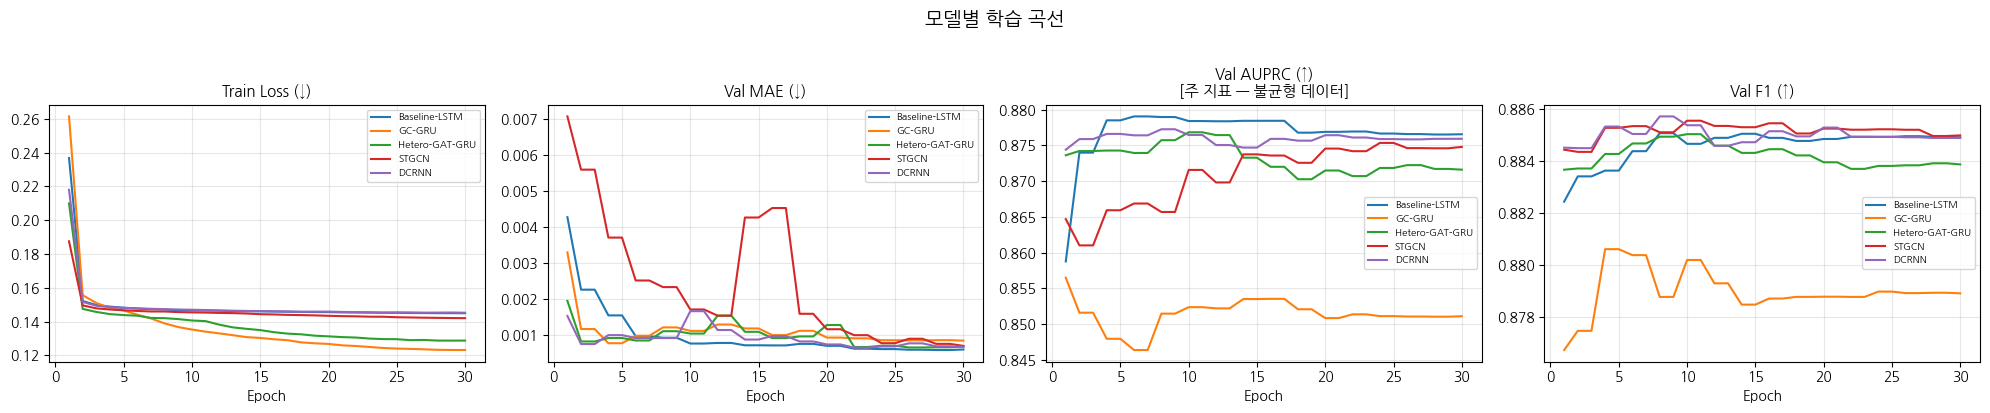

In [33]:
# ── 학습 곡선 시각화 (4개 서브플롯) ─────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
colors = plt.cm.tab10.colors

for i, (name, res) in enumerate(RESULTS.items()):
    hist = res['history']
    ep   = range(1, len(hist['train_loss']) + 1)
    c    = colors[i]
    axes[0].plot(ep, hist['train_loss'], color=c, label=name)
    axes[1].plot(ep, hist['val_mae'],    color=c, label=name)
    axes[2].plot(ep, hist['val_auprc'],  color=c, label=name)
    axes[3].plot(ep, hist['val_f1'],     color=c, label=name)

titles = [
    'Train Loss (↓)',
    'Val MAE (↓)',
    'Val AUPRC (↑)\n[주 지표 — 불균형 데이터]',
    'Val F1 (↑)',
]
for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('모델별 학습 곡선', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('./model_comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()

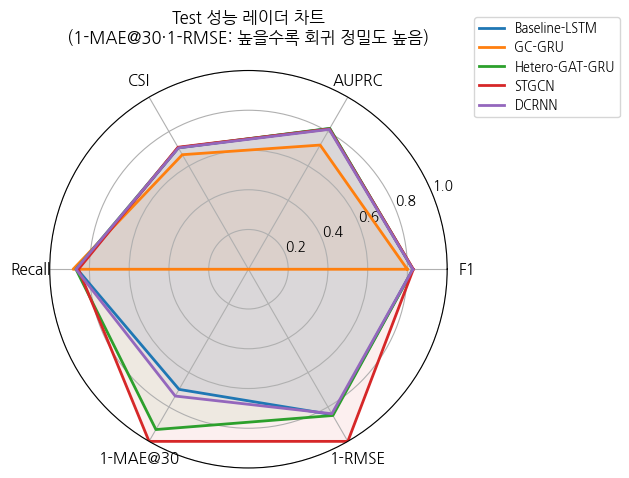

In [34]:
# ── 레이더 차트 (Test 지표 비교) ─────────────────────────────────
# 지표: F1, AUPRC, CSI, Recall, 1-MAE@30(회귀 품질), 1-RMSE
RADAR_METRICS = ['F1', 'AUPRC', 'CSI', 'Recall', '1-MAE@30', '1-RMSE']
model_names   = list(RESULTS.keys())


def build_radar_vals(results):
    raw = {
        'F1'     : [results[n]['test']['F1']           for n in model_names],
        'AUPRC'  : [results[n]['test']['AUPRC']        for n in model_names],
        'CSI'    : [results[n]['test']['CSI']           for n in model_names],
        'Recall' : [results[n]['test']['Recall']        for n in model_names],
        'MAE@30' : [results[n]['test'].get('MAE@30min', float('nan')) for n in model_names],
        'RMSE'   : [results[n]['test']['RMSE']          for n in model_names],
    }

    def _norm_inv(vals):
        """낮을수록 좋은 지표 → 1-정규화 (높을수록 좋게 변환)"""
        lo = min(v for v in vals if not np.isnan(v))
        hi = max(v for v in vals if not np.isnan(v))
        return [1 - (v - lo) / (hi - lo + 1e-9) if not np.isnan(v) else 0.0
                for v in vals]

    return {
        'F1'      : raw['F1'],
        'AUPRC'   : raw['AUPRC'],
        'CSI'     : raw['CSI'],
        'Recall'  : raw['Recall'],
        '1-MAE@30': _norm_inv(raw['MAE@30']),
        '1-RMSE'  : _norm_inv(raw['RMSE']),
    }


radar  = build_radar_vals(RESULTS)
N_met  = len(RADAR_METRICS)
angles = [n / N_met * 2 * np.pi for n in range(N_met)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': 'polar'})
for i, name in enumerate(model_names):
    vals = [radar[m][i] for m in RADAR_METRICS] + [radar[RADAR_METRICS[0]][i]]
    ax.plot(angles, vals, color=colors[i], linewidth=2, label=name)
    ax.fill(angles, vals, color=colors[i], alpha=0.07)

ax.set_thetagrids(np.degrees(angles[:-1]), RADAR_METRICS, fontsize=11)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), fontsize=9)
ax.set_title('Test 성능 레이더 차트\n(1-MAE@30·1-RMSE: 높을수록 회귀 정밀도 높음)',
             pad=20, fontsize=12)
plt.tight_layout()
plt.savefig('./model_comparison_radar.png', dpi=150, bbox_inches='tight')
plt.show()

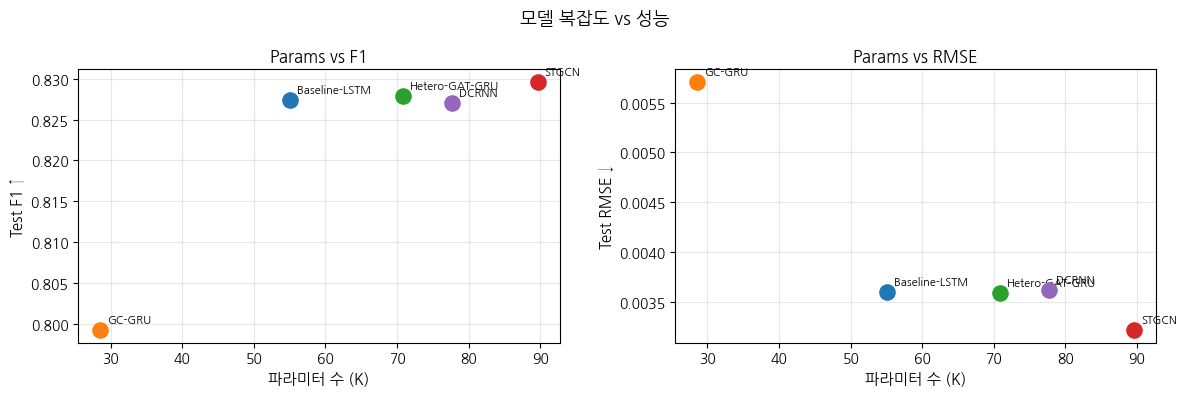

In [35]:
# ── 파라미터 수 vs 성능 산점도 ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, ['F1', 'RMSE']):
    arrow = '↑' if metric == 'F1' else '↓'
    for i, (name, res) in enumerate(RESULTS.items()):
        x = res['n_params'] / 1e3
        y = res['test'][metric]
        ax.scatter(x, y, s=120, color=colors[i], zorder=5)
        ax.annotate(name, (x, y), textcoords='offset points',
                    xytext=(5, 5), fontsize=8)
    ax.set_xlabel('파라미터 수 (K)', fontsize=11)
    ax.set_ylabel(f'Test {metric} {arrow}', fontsize=11)
    ax.set_title(f'Params vs {metric}', fontsize=12)
    ax.grid(alpha=0.3)

plt.suptitle('모델 복잡도 vs 성능', fontsize=13)
plt.tight_layout()
plt.savefig('./model_comparison_params.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. 결론 및 권장 모델

### 모델 선택 가이드

| 상황 | 권장 모델 | 이유 |
|------|----------|------|
| **운영 배포 (실시간 추론)** | STGCN | GRU 없이 병렬처리 → 지연 최소 |
| **예측 정확도 최우선** | DCRNN / Hetero-GAT-GRU | 확산 컨볼루션 / 어텐션으로 공간 컨텍스트 풍부 |
| **빠른 프로토타입** | GC-GRU | 간단한 구현, 합리적 성능 |
| **공간 정보 효과 검증** | Baseline-LSTM vs 나머지 | 그래프 사용 이득 정량화 |

### 다음 실험 계획

1. **강우량 피처 추가**: AWS 데이터 확보 → `sewer_normalized.parquet` 재생성 → `F_SEWER=10`으로 재학습
2. **하이퍼파라미터 탐색**: Optuna로 `HIDDEN`, `CHEB_K`, `DIFF_K`, `LR` 자동 튜닝
3. **앙상블**: DCRNN + Hetero-GAT-GRU 앙상블로 극단적 침수 이벤트 탐지 강화
4. **인과 그래프**: 상관 분석의 lag 정보를 엣지 특성(delay)으로 추가
5. **다중 스텝 디코더**: Seq2Seq 구조로 T_OUT 확장 (최대 6스텝 = 1시간 예측)